# Gaussian Process Regression for Yield Prediction
This notebook implements the GPR model for the ML Hackathon, incorporating physical constraints, thermodynamic feature engineering, and robust Bayesian uncertainty quantification.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

# --- PATH CONFIGURATION ---
# Set this to True if you are running in Google Colab
RUNNING_IN_COLAB = True

if RUNNING_IN_COLAB:
    # By default, Colab uploads go to the current directory (/content/)
    TRAIN_PATH = 'train_dataset.csv'
    TEST_PATH = 'test_dataset.csv'
    PREDS_DIR = '.'
else:
    # Default local paths
    TRAIN_PATH = '../datasets/train_dataset.csv'
    TEST_PATH = '../datasets/test_dataset.csv'
    PREDS_DIR = '../predictions'

os.makedirs(PREDS_DIR, exist_ok=True)


In [3]:
# Load datasets
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

def engineer_features(df):
    df = df.copy()
    # 1. Residence-Time Proxy (L/Q)
    df['residence_proxy'] = df['length_m'] / df['flow_rate_L_min']
    # 2. Mean Temperature (inlet + jacket) / 2
    df['mean_T'] = (df['inlet_temperature_K'] + df['jacket_temperature_K']) / 2
    return df

# Apply feature engineering
X_train_full = engineer_features(train_df.drop(columns=['overall_yield']))
y_train_full = train_df['overall_yield']
X_test = engineer_features(test_df)

print(f"Training features shape: {X_train_full.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (150, 7)
Testing features shape: (50, 7)


In [4]:
# GPR is highly sensitive to feature scales (it relies on distance measurements).
# We strictly scale all features to mean=0, std=1.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

In [5]:
# Define the kernel
# Matern kernel allows for smooth but slightly rougher functions than RBF, good for real physical processes.
# WhiteKernel explicitly models the inherent measurement noise in the data.
kernel = 1.0 * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=1.0)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    random_state=42,
    normalize_y=True # Important for targets not centered around 0
)

# Robust Cross Validation
rkf = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)
rmse_scores = []

for train_idx, val_idx in rkf.split(X_train_scaled):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    # Train
    gpr.fit(X_tr, y_tr)

    # Predict
    y_pred, _ = gpr.predict(X_val, return_std=True)

    # Clip predictions to physical bounds [0, 100]
    y_pred_clipped = np.clip(y_pred, 0, 100)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_val, y_pred_clipped))
    rmse_scores.append(rmse)

print(f"Repeated CV RMSE: {np.mean(rmse_scores):.4f} +/- {np.std(rmse_scores):.4f}")

Repeated CV RMSE: 20.9064 +/- 2.3391


In [6]:
# Train on full dataset
print("Training final model on full dataset...")
gpr.fit(X_train_scaled, y_train_full)

print("\nOptimized Kernel parameters after fitting:")
print(gpr.kernel_)

# Predict on test set
# Also extract standard deviation (uncertainty) to show judges
y_test_pred, y_test_std = gpr.predict(X_test_scaled, return_std=True)

# Apply physical constraints
y_test_pred_clipped = np.clip(y_test_pred, 0, 100)

# Prepare submission
submission = pd.DataFrame({
    'overall_yield': np.round(y_test_pred_clipped, 3)
})

# Save predictions
submission_path = f'{PREDS_DIR}/GPR_predictions.csv'
submission.to_csv(submission_path, index=False)
print(f"\nPredictions saved to {submission_path}")

# Display a few predictions with their uncertainty (great for Phase 2 pitch)
print("\nSample Predictions with Uncertainty:")
for i in range(5):
    print(f"Test case {i+1}: Yield = {y_test_pred_clipped[i]:.2f}% +/- {y_test_std[i]:.2f}%")

Training final model on full dataset...

Optimized Kernel parameters after fitting:
1.05**2 * Matern(length_scale=2.14, nu=1.5) + WhiteKernel(noise_level=0.0505)

Predictions saved to ./GPR_predictions.csv

Sample Predictions with Uncertainty:
Test case 1: Yield = 54.47% +/- 17.06%
Test case 2: Yield = 100.00% +/- 16.76%
Test case 3: Yield = 35.57% +/- 27.24%
Test case 4: Yield = 100.00% +/- 26.98%
Test case 5: Yield = 0.00% +/- 19.09%


## Visualizations
The following plots help visualize the model's behavior and are highly recommended for the Phase 2 pitch.

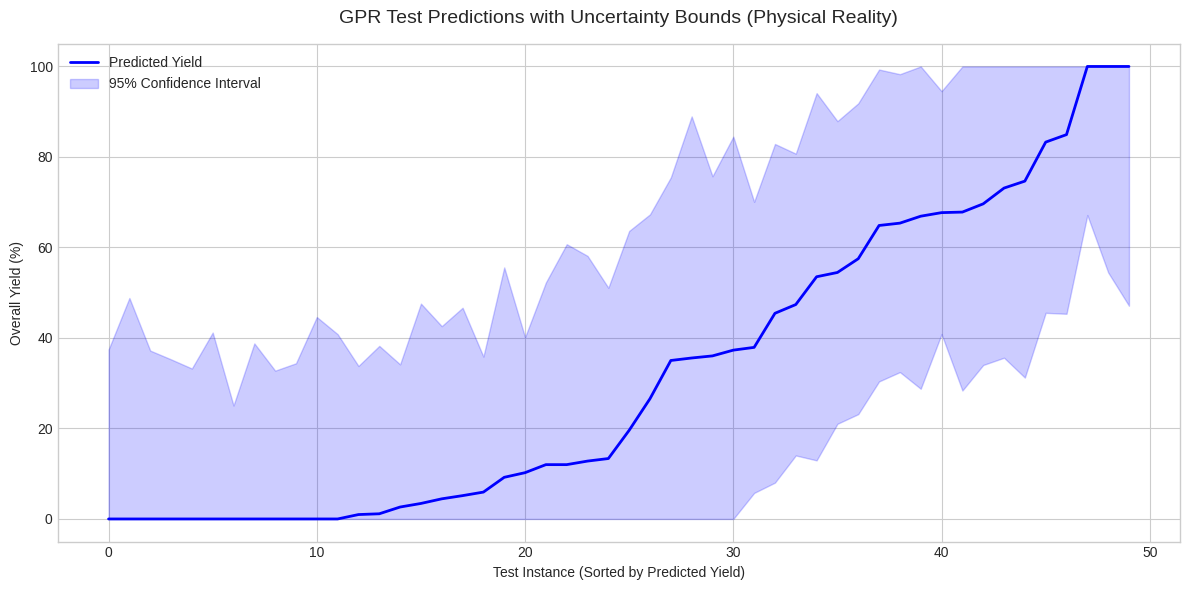

In [7]:
# Visualization: Prediction Uncertainty
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

# Sort test predictions for better visualization of the curve
sort_idx = np.argsort(y_test_pred_clipped)
y_sorted = y_test_pred_clipped[sort_idx]
std_sorted = y_test_std[sort_idx]
x_axis = np.arange(len(y_sorted))

plt.plot(x_axis, y_sorted, 'b-', label='Predicted Yield', linewidth=2)

# Plot 95% Confidence Interval (1.96 * standard deviation)
lower_bound = np.clip(y_sorted - 1.96 * std_sorted, 0, 100)
upper_bound = np.clip(y_sorted + 1.96 * std_sorted, 0, 100)
plt.fill_between(x_axis, lower_bound, upper_bound, alpha=0.2, color='blue', label='95% Confidence Interval')

plt.title('GPR Test Predictions with Uncertainty Bounds (Physical Reality)', fontsize=14, pad=15)
plt.xlabel('Test Instance (Sorted by Predicted Yield)')
plt.ylabel('Overall Yield (%)')
plt.legend()
plt.tight_layout()
plt.show()
